In [23]:
import glob
import torch
import numpy as np
import pop_tools
import xarray as xr
import xesmf as xe
import warnings
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

# Ignore messages
warnings.filterwarnings("ignore", message="Latitude is outside of \\[-90, 90\\]")
warnings.filterwarnings("ignore", message="Duplicate dimension names present.*",
                        category=UserWarning, module="xarray.namedarray.core")

# Client
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### Set up rectilinear grids and subsetting

In [44]:
# ---------- Native grids ----------

low_src = pop_tools.get_grid('POP_gx1v7')     # ~1° grid
high_src = pop_tools.get_grid('POP_tx0.1v2')  # ~0.1° grid

# ---------- 40N subset ----------

rows_low = np.where(np.any(low_src.TLAT >= 40, axis=1))[0]
rows_high = np.where(np.any(high_src.TLAT >= 40, axis=1))[0]

jmin_low = rows_low.min()
jmin_high = rows_high.min()

lat_low = low_src.TLAT.isel(nlat=slice(jmin_low, None))
lon_low = low_src.TLONG.isel(nlat=slice(jmin_low, None))

lat_high = high_src.TLAT.isel(nlat=slice(jmin_high, None))
lon_high = high_src.TLONG.isel(nlat=slice(jmin_high, None))

# ---------- Source grids ----------

src_grid_low = xr.Dataset(
    {"lat": (["nlat", "nlon"], lat_low.data),
     "lon": (["nlat", "nlon"], lon_low.data)}
)

src_grid_high = xr.Dataset(
    {"lat": (["nlat", "nlon"], lat_high.data),
     "lon": (["nlat", "nlon"], lon_high.data)}
)

# ---------- Destination grids ----------

dst_grid_lr = xr.Dataset(
    {"lat": (["lat"], np.arange(40, 90.1, 1.0)),
     "lon": (["lon"], np.arange(0, 360, 1.0))}
)

dst_grid_hr = xr.Dataset(
    {"lat": (["lat"], np.arange(40, 90.001, 0.1)),
     "lon": (["lon"], np.arange(0, 360, 0.1))}
)

# ---------- Build regridders ----------

regridder_low = xe.Regridder(
    src_grid_low,
    dst_grid_lr,
    periodic=True,
    method="bilinear",
    filename="gx1v7_to_latlon_1deg.nc",
    reuse_weights=True
)

regridder_high = xe.Regridder(
    src_grid_high,
    dst_grid_hr,
    periodic=True,
    method="bilinear",
    filename="tx0.1v2_to_latlon_0.1deg.nc",
    reuse_weights=True
)

regridder_coarse = xe.Regridder(
    src_grid_high,
    dst_grid_lr,
    periodic=True,
    method="bilinear",
    filename="tx0.1v2_to_latlon_1deg.nc",
    reuse_weights=True
)

print("Regridder weight files done/reused.")

# ---------- Region select ----------

bbox = {"lon_min": -130, "lon_max": -80, "lat_min": 60, "lat_max": 80}
lon_min = bbox["lon_min"] % 360
lon_max = bbox["lon_max"] % 360

print("Grid setup done.")

Regridder weight files done/reused.
Grid setup done.


#### Collect files

In [45]:
def collect_files(dirs, vars, start_year):
    out = []
    for d in dirs:
        member_files = {}
        for v in vars:
            c = comps[v]
            pattern = f"{d}/{c}/proc/tseries/month_1/*.{v}.*.nc"
            files = sorted(glob.glob(pattern))

            # Keep only files from 1920/2006 on
            filtered = []
            for f in files:
                year = int(f.split('.')[-2][:4])
                if year >= start_year:
                    filtered.append(f)

            member_files[v] = filtered

        out.append(member_files)
    return out


# ---------- Directories on glade ----------

low_res_dirs = sorted(glob.glob('/gdex/data/d651030/BHIST/*'))   # /BRCP85
high_res_dirs = sorted(glob.glob('/gdex/data/d651007/b.e13.*'))  # /d651009

# ---------- Variables ----------

low_vars = ['hi', 'Tsfc', 'TEMP', 'uvel', 'vvel']
target_var = ['hi']
comps = {
    'hi': 'ice',
    'Tsfc': 'ice',
    'TEMP': 'ocn',
    'uvel': 'ice',
    'vvel': 'ice',
}

# ---------- Collect files ----------

low_res_files = collect_files(low_res_dirs, low_vars, start_year=1920)  # 2006
high_res_files = collect_files(high_res_dirs, target_var, start_year=1920)  # 2006
coarsen_files = collect_files(high_res_dirs, low_vars, start_year=1920)  # 2006

print('Low-res  | # ens:', len(low_res_files), '| # vars:', len(low_res_files[0]))
print('High-res | # ens:', len(high_res_files), '| # vars:', len(high_res_files[0]))
print('Coarsen  | # ens:', len(coarsen_files), '| # vars:', len(coarsen_files[0]))

Low-res  | # ens: 10 | # vars: 5
High-res | # ens: 10 | # vars: 1
Coarsen  | # ens: 10 | # vars: 5


#### Low resolution

In [ ]:
def process_file(args):

    file, var = args

    # Open file
    ds = xr.open_dataset(file, decode_timedelta=(var == "TEMP"))
    ds = ds[var]

    # Get surface layer for ocean variable
    if var == "TEMP":
        ds = ds.isel(z_t=0, drop=True)
    else:
        ds = ds.rename({"nj": "nlat", "ni": "nlon"})

    # Subset to 40N
    da = ds.isel(nlat=slice(jmin_low, None))

    # Regrid
    da_reg = regridder_low(da)

    # Select region
    da_reg = da_reg.sel(
        lat=slice(bbox["lat_min"], bbox["lat_max"]),
        lon=slice(lon_min, lon_max)
    )

    ds.close()

    # Convert NaNs to zero
    da_reg = da_reg.fillna(0).astype(np.float32)

    return da_reg


def load_wrapper(files, var):
    args = [(f, var) for f in files]

    with ProcessPoolExecutor(max_workers=4) as exe:
        data_list = list(exe.map(process_file, args))

    return xr.concat(data_list, dim="time")


# ---------- Build X (Low-Res Predictors) ----------
X_list = []

for i, member in enumerate(low_res_files):
    print(f"Processing Ensemble #{i+1}...")

    channels = [load_wrapper(member[var], var) for var in low_vars]

    # Align time across channels
    min_t = min(c.sizes["time"] for c in channels)
    channels = [c.isel(time=slice(0, min_t)) for c in channels]

    member_da = xr.concat(channels, dim="channel")  # stack channels
    member_da.name = "X"  # rename var
    member_da = member_da.expand_dims({"ensemble": [i]})  # add ensemble dim

    X_list.append(member_da)

# Align time across all ensembles
min_t_global = min(x.sizes["time"] for x in X_list)
X_list = [x.isel(time=slice(0, min_t_global)) for x in X_list]

# Combine all ensembles
X_ds = xr.concat(X_list, dim="ensemble")

# Add coords and metadata
if "channel" in X_ds.dims and "channel" not in X_ds.coords:
    X_ds = X_ds.assign_coords(channel=np.arange(X_ds.sizes["channel"]))

X_ds.attrs["description"] = (
    "Low-resolution CESM predictor data, regridded to rectilinear lat/lon and "
    "subset to 40N+ region."
)
X_ds.attrs["notes"] = "NaNs filled with zero, lat/lon are 2D actual coordinates"
X_ds.attrs["source"] = "POP/POP_tools"
X_ds.attrs["created_by"] = "Sky Gale"
X_ds.attrs["create_date"] = "Jun 1 2026"

# ---------- Swap time + channel axes ----------
X_ds = X_ds.transpose("ensemble", "time", "channel", "lat", "lon")

# ---------- Save ----------
save_path = '/glade/work/skygale/_projects/SeaIceDownscaling/data/X_perfect_model_exp.nc'
X_ds.to_netcdf(save_path)
print("\nSaved to:", save_path)

#### Low resolution (coarsened)

In [19]:
def process_file(args):

    file, var = args

    # Open file
    ds = xr.open_dataset(file, decode_timedelta=(var == "TEMP"))
    ds = ds[var]

    # Get surface layer for ocean variable
    if var == "TEMP":
        ds = ds.isel(z_t=0, drop=True)
    else:
        ds = ds.rename({"nj": "nlat", "ni": "nlon"})

    # Subset to 40N
    da = ds.isel(nlat=slice(jmin_high, None))

    # Regrid to coarse resolution
    da_reg = regridder_coarse(da)

    # Select region
    da_reg = da_reg.sel(
        lat=slice(bbox["lat_min"], bbox["lat_max"]),
        lon=slice(lon_min, lon_max)
    )

    ds.close()

    # Convert NaNs to zero
    da_reg = da_reg.fillna(0).astype(np.float32)

    return da_reg


def load_wrapper(files, var):
    args = [(f, var) for f in files]

    with ProcessPoolExecutor(max_workers=2) as exe:
        data_list = list(exe.map(process_file, args))

    return xr.concat(data_list, dim="time")


# ---------- Build X (Low-Res Predictors) ----------
X_list = []

for i, member in enumerate(coarsen_files):
    print(f"Processing Ensemble #{i+1}...")

    channels = [load_wrapper(member[var], var) for var in low_vars]

    # Align time across channels
    min_t = min(c.sizes["time"] for c in channels)
    channels = [c.isel(time=slice(0, min_t)) for c in channels]

    member_da = xr.concat(channels, dim="channel")  # stack channels
    member_da.name = "X"  # rename var
    member_da = member_da.expand_dims({"ensemble": [i]})  # add ensemble dim

    X_list.append(member_da)

# Align time across all ensembles
min_t_global = min(x.sizes["time"] for x in X_list)
X_list = [x.isel(time=slice(0, min_t_global)) for x in X_list]

# Combine all ensembles
X_ds = xr.concat(X_list, dim="ensemble")

# Add coords and metadata
if "channel" in X_ds.dims and "channel" not in X_ds.coords:
    X_ds = X_ds.assign_coords(channel=np.arange(X_ds.sizes["channel"]))

X_ds.attrs["description"] = (
    "Low-resolution (coarsened) CESM predictor data, regridded to rectilinear lat/lon and "
    "subset to 40N+ region."
)
X_ds.attrs["notes"] = "NaNs filled with zero, lat/lon are 2D actual coordinates"
X_ds.attrs["source"] = "POP/POP_tools"
X_ds.attrs["created_by"] = "Sky Gale"
X_ds.attrs["create_date"] = "Jun 1 2026"

# ---------- Swap time + channel axes ----------
X_ds = X_ds.transpose("ensemble", "time", "channel", "lat", "lon")

# ---------- Save ----------
save_path = '/glade/work/skygale/_projects/SeaIceDownscaling/data/X_perfmodexp.nc'
X_ds.to_netcdf(save_path)
print("\nSaved to:", save_path)

Processing Ensemble #1...
Processing Ensemble #2...
Processing Ensemble #3...
Processing Ensemble #4...
Processing Ensemble #5...
Processing Ensemble #6...
Processing Ensemble #7...
Processing Ensemble #8...
Processing Ensemble #9...
Processing Ensemble #10...

Saved to: /glade/work/skygale/_projects/SeaIceDownscaling/data/X_perfmodexp.nc


#### High resolution

In [46]:
def process_file_hi(args):

    file, target_var = args

    # Open file
    ds = xr.open_dataset(file)
    ds = ds[target_var[0]]
    ds = ds.rename({"nj": "nlat", "ni": "nlon"})

    # Subset to 40N
    da = ds.isel(nlat=slice(jmin_high, None))

    # Regrid
    da_reg = regridder_high(da)

    # Select region
    da_reg = da_reg.sel(
        lat=slice(bbox["lat_min"], bbox["lat_max"]),
        lon=slice(lon_min, lon_max)
    )

    ds.close()

    # Convert NaNs to zero
    da_reg = da_reg.fillna(0).astype(np.float32)

    return da_reg


def load_wrapper_hi(files, target_var):

    args = [(f, target_var) for f in files]

    with ProcessPoolExecutor(max_workers=2) as exe:
        data_list = list(exe.map(process_file_hi, args))

    return xr.concat(data_list, dim="time")


# ---------- Build Y (High-Res Target) ----------
Y_list = []

for i, member in enumerate(high_res_files):
    print(f"Processing Ensemble #{i+1}...")

    var_da = load_wrapper_hi(member[target_var[0]], target_var)
    var_da.name = "Y"

    # Add ensemble and channel dims
    member_da = var_da.expand_dims({"ensemble": [i], "channel": [0]})

    # Ensure correct dim order: (ensemble, time, channel, lat, lon)
    member_da = member_da.transpose("ensemble", "time", "channel", "lat", "lon")

    Y_list.append(member_da)

# Combine all ensembles
Y_ds = xr.concat(Y_list, dim="ensemble")

# Add coords if needed
if "channel" in Y_ds.dims and "channel" not in Y_ds.coords:
    Y_ds = Y_ds.assign_coords(channel=np.arange(Y_ds.sizes["channel"]))

# Add metadata
Y_ds.attrs["description"] = (
    "High-resolution CESM predictand data, regridded to rectilinear lat/lon and "
    "subset to 40N+ region."
)
Y_ds.attrs["notes"] = "NaNs filled with zero, lat/lon are 2D actual coordinates"
Y_ds.attrs["source"] = "POP/POP_tools"
Y_ds.attrs["created_by"] = "Sky Gale"
Y_ds.attrs["create_date"] = "Jun 1 2026"

# ---------- Save ----------
save_path = '/glade/work/skygale/_projects/SeaIceDownscaling/data/Y_perfmodexp.nc'
Y_ds.to_netcdf(save_path)
print("\nSaved to:", save_path)

Processing Ensemble #1...
Processing Ensemble #2...
Processing Ensemble #3...
Processing Ensemble #4...
Processing Ensemble #5...
Processing Ensemble #6...
Processing Ensemble #7...
Processing Ensemble #8...
Processing Ensemble #9...
Processing Ensemble #10...

Saved to: /glade/work/skygale/_projects/SeaIceDownscaling/data/Y_perfmodexp.nc


#### Check shapes

In [61]:
X = xr.open_dataset('/glade/work/skygale/_projects/SeaIceDownscaling/data/X_perfmodexp.nc').X
Y = xr.open_dataset('/glade/work/skygale/_projects/SeaIceDownscaling/data/Y_perfmodexp.nc').Y

# Select data
llat, llon = X.lat.values, X.lon.values
hlat, hlon = Y.lat.values, Y.lon.values
X = X.values
Y = Y.values

# Clip to max thickness (remove spurious CESM1 artifacts)
X = np.clip(X, None, 6.0)
Y = np.clip(Y, None, 6.0)

# Land-sea mask
high_src = pop_tools.get_grid('POP_tx0.1v2')
mask_native = (high_src.KMT > 0).astype(np.float32)
mask_sel = mask_native.isel(nlat=slice(jmin_high, None))
mask_reg = regridder_high(mask_sel)
mask = mask_reg.sel(
    lat=slice(bbox["lat_min"], bbox["lat_max"]), lon=slice(lon_min, lon_max)
)

print(mask.shape, X.shape, Y.shape)

(200, 501) (10, 1032, 5, 21, 51) (10, 1032, 1, 200, 501)


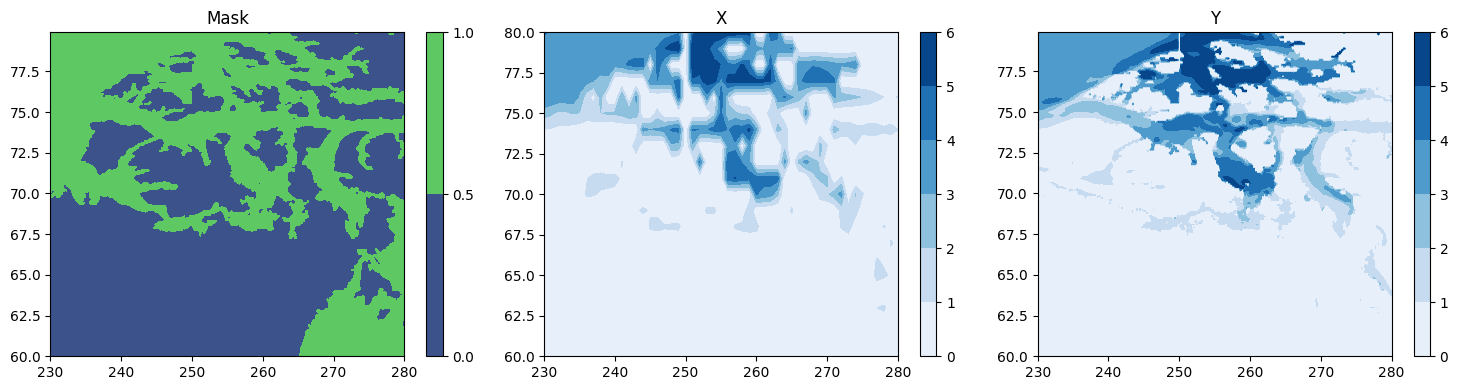

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
levels = np.linspace(0, 6, 7)

cf1 = axes[0].contourf(hlon, hlat, mask, levels=[0, 0.5, 1])
fig.colorbar(cf1, ax=axes[0])
axes[0].set_title("Mask")

cf2 = axes[1].contourf(llon, llat, X[0, 0, 0], levels=levels, cmap='Blues')
fig.colorbar(cf2, ax=axes[1])
axes[1].set_title("X")

cf3 = axes[2].contourf(hlon, hlat, Y[0, 0, 0], levels=levels, cmap='Blues')
fig.colorbar(cf3, ax=axes[2])
axes[2].set_title("Y")

plt.tight_layout()
plt.show()